## Import Necessary Packages

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import trxrd
from globals import *

%matplotlib widget

## Define File Paths

In [ ]:
# Main diffraction data folder
data_path = DATA_PATH

# Check number of files in folder 
file_names = sorted(data_path.glob(f"{SCAN_NAME}*.tif"))
print(f"{len(file_names)} TIFF files found in {data_path}.")

# Detector mask file
mask_file = MASK_FILE
print(f"Using mask file: {mask_file}")

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3.
Using mask file: C:\Users\lheald\Documents\Guzelturk_Lab\TRXRDPython\testdata\mask_2021_dec.tif


## Import Images

In [ ]:
data_dict = trxrd.get_image_details(
    folder_path=DATA_PATH,
    sample_name=SCAN_NAME,   
    sort=True,
    filter_data=False,
    plot=True,
)

print(data_dict.keys())
print("Images shape:", data_dict["images"].shape)
print("Counts shape:", data_dict["counts"].shape)
print("Unique delays:", np.unique(data_dict["delay"]))

884 TIFF files found in \\s7data\beams46\7IDC\Cotts\2025_11Exp\BTO400_S3 with scan name BTO400nmS3_240Ksurv3.


## Apply Detector Mask

c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:1048: RuntimeWarning: invalid value encountered in log1p
  log_original = np.log1p(original_image)
c:\Users\lheald\Documents\Guzelturk_Lab\trxrd\trxrd.py:1049: RuntimeWarning: invalid value encountered in log1p
  log_masked = np.log1p(masked_image)


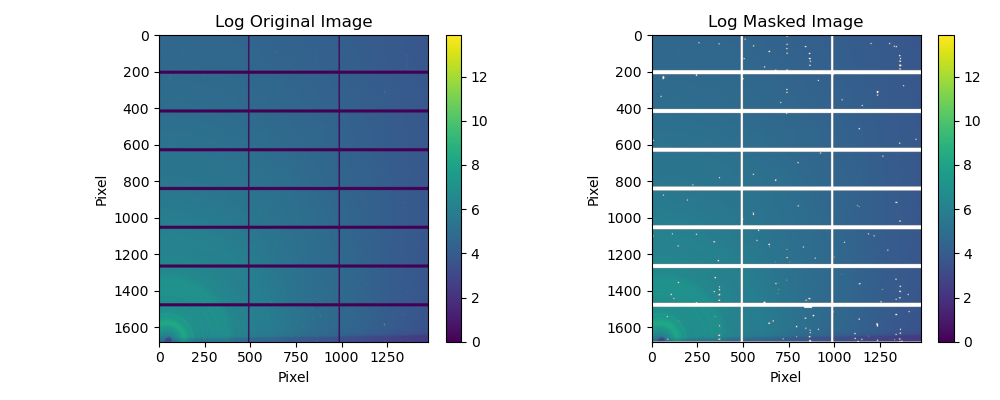

In [ ]:
masked_images = trxrd.apply_nan_mask(
    data_dict["images"],
    mask_path=MASK_FILE,
    plot=True,
    image_index=0,
)

data_dict["images"] = masked_images

## Investigation Integration Methods

Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
SUCCESS: 2) method=("bbox", "histogram", "cython")
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
SUCCESS: 3) method=("bbox", "csr", "cython")
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
SUCCESS: 4) method=("full", "csr", "cython")
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
SUCCESS: 5) method=("full", "lut", "cython")


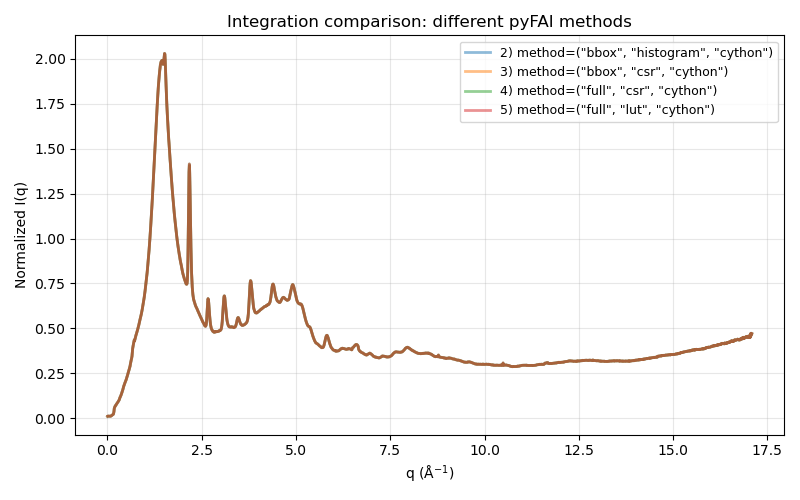

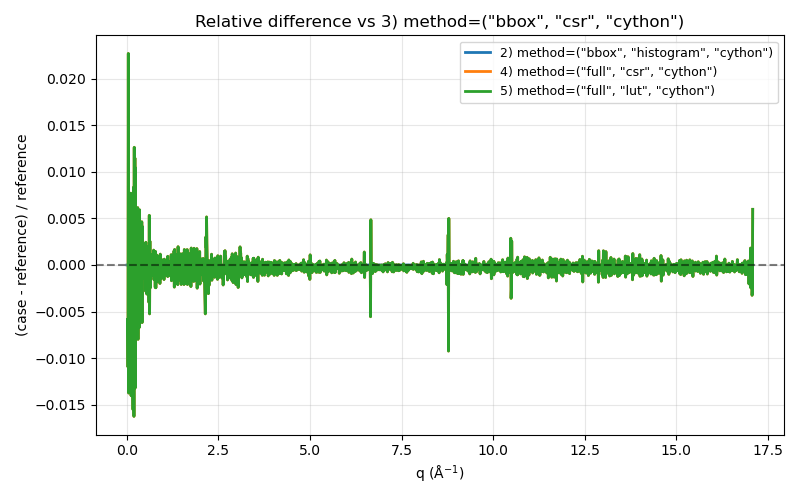

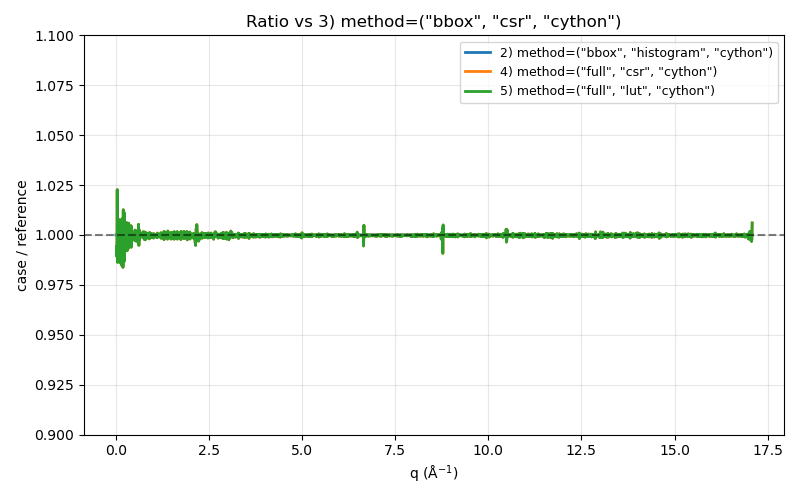


WORKING CASES
2) method=("bbox", "histogram", "cython")
method: ('bbox', 'histogram', 'cython')
{'pixel1': 0.000172, 'pixel2': 0.000172, 'distance': 0.17236, 'wavelength': 3.9738514824147314e-11, 'tilt_angle': np.float64(0.0), 'tilt_plane_rotation': np.float64(1.5707963267948966), 'rot1': np.float64(0.0), 'rot2': np.float64(0.0), 'rot3': 0.0, 'polarization_factor': 0.999, 'use_custom_polarization': False, 'integration_function': 'integrate1d', 'correct_solid_angle': True}
--------------------------------------------------------------------------------
3) method=("bbox", "csr", "cython")
method: ('bbox', 'csr', 'cython')
{'pixel1': 0.000172, 'pixel2': 0.000172, 'distance': 0.17236, 'wavelength': 3.9738514824147314e-11, 'tilt_angle': np.float64(0.0), 'tilt_plane_rotation': np.float64(1.5707963267948966), 'rot1': np.float64(0.0), 'rot2': np.float64(0.0), 'rot3': 0.0, 'polarization_factor': 0.999, 'use_custom_polarization': False, 'integration_function': 'integrate1d', 'correct_solid_angl

In [ ]:
# ----------------------------
# choose one image
# ----------------------------
idx = 0  # change as needed
image = data_dict["images"][idx]
center = (CENTER_X, CENTER_Y)

# use the same mask you normally use
# examples:
# integration_mask = None
integration_mask = np.isnan(image)
# integration_mask = your_mask_variable

# ----------------------------
# common settings
# ----------------------------
common_kwargs = dict(
    images=image,
    centers_xy=center,
    npt=2000,
    unit="q_A^-1",
    radial_range=None,
    nan_radial_range=None,
    azimuth_range=None,
    integration_mask=integration_mask,
    dark=None,
    flat=None,
    polarization_factor=0.999,         # keep fixed for this test
    use_custom_polarization=False,     # keep fixed for this test
    integration_function="integrate1d",  # keep fixed for this test
    correct_solid_angle=True,          # keep fixed for this test
)

# ----------------------------
# helper
# ----------------------------
def normalize_to_range(q, I, qmin=1.0, qmax=3.0):
    qmask = (q >= qmin) & (q <= qmax) & np.isfinite(I)
    if not np.any(qmask):
        raise ValueError(f"No valid points in normalization range {qmin} to {qmax}")
    return I / np.nanmean(I[qmask])

# ----------------------------
# method cases
# ----------------------------
cases = {
    '2) method=("bbox", "histogram", "cython")': dict(
        method=("bbox", "histogram", "cython"),
    ),
    '3) method=("bbox", "csr", "cython")': dict(
        method=("bbox", "csr", "cython"),
    ),
    '4) method=("full", "csr", "cython")': dict(
        method=("full", "csr", "cython"),
    ),
    '5) method=("full", "lut", "cython")': dict(
        method=("full", "lut", "cython"),
    ),
}

results = {}
failed_cases = {}

# ----------------------------
# run method cases
# ----------------------------
for label, opts in cases.items():
    try:
        res = trxrd.azimuthal_average_pyfai(
            **common_kwargs,
            **opts,
            return_dict=True,
            error_mode="raise",
            max_workers=1,
            progress_interval=1,
        )

        q = res["radial"]
        I = res["profiles"][0]
        I_norm = normalize_to_range(q, I, qmin=1.0, qmax=3.0)

        results[label] = {
            "q": q,
            "I": I,
            "I_norm": I_norm,
            "meta": res["geometry"],
            "method": opts["method"],
        }

        print(f"SUCCESS: {label}")

    except Exception as e:
        failed_cases[label] = str(e)
        print(f"FAILED:  {label}")
        print(f"         {type(e).__name__}: {e}")

# ----------------------------
# stop if nothing worked
# ----------------------------
if len(results) == 0:
    raise RuntimeError("All method cases failed. Check method support in your pyFAI version.")

# ----------------------------
# overlay normalized curves
# ----------------------------
plt.figure(figsize=(8, 5))
for label, out in results.items():
    plt.plot(out["q"], out["I_norm"], label=label, lw=2, alpha=0.5)

plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Normalized I(q)")
plt.title("Integration comparison: different pyFAI methods")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# choose reference case
# ----------------------------
preferred_ref = '3) method=("bbox", "csr", "cython")'
if preferred_ref not in results:
    preferred_ref = list(results.keys())[0]

ref_label = preferred_ref
q_ref = results[ref_label]["q"]
I_ref = results[ref_label]["I_norm"]

# ----------------------------
# relative differences to reference
# ----------------------------
plt.figure(figsize=(8, 5))
for label, out in results.items():
    if label == ref_label:
        continue

    # interpolate in case q grids differ slightly
    I_interp = np.interp(q_ref, out["q"], out["I_norm"], left=np.nan, right=np.nan)
    rel = (I_interp - I_ref) / I_ref
    plt.plot(q_ref, rel, label=label, lw=2)

plt.axhline(0, color="k", ls="--", alpha=0.5)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("(case - reference) / reference")
plt.title(f"Relative difference vs {ref_label}")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# optional: zoomed ratio plot
# ----------------------------
plt.figure(figsize=(8, 5))
for label, out in results.items():
    if label == ref_label:
        continue

    I_interp = np.interp(q_ref, out["q"], out["I_norm"], left=np.nan, right=np.nan)
    ratio = I_interp / I_ref
    plt.plot(q_ref, ratio, label=label, lw=2)

plt.axhline(1, color="k", ls="--", alpha=0.5)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("case / reference")
plt.title(f"Ratio vs {ref_label}")
plt.ylim(0.9, 1.1)   # adjust as needed
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# print the options used
# ----------------------------
print("\nWORKING CASES")
print("=" * 80)
for label, out in results.items():
    print(label)
    print("method:", out["method"])
    print(out["meta"])
    print("-" * 80)

# ----------------------------
# print failed cases
# ----------------------------
if failed_cases:
    print("\nFAILED CASES")
    print("=" * 80)
    for label, err in failed_cases.items():
        print(label)
        print(err)
        print("-" * 80)

## Investigating Polarization Correction

Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.


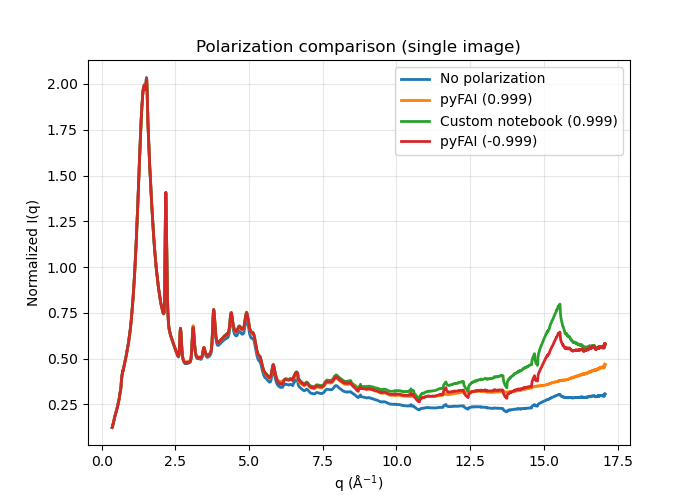

In [ ]:
# --- pick a single image ---
idx = 0  # change if needed
image = data_dict["images"][idx]
center = (CENTER_X, CENTER_Y)  
integration_mask = np.isnan(image)

# --- common settings ---
common_kwargs = dict(
    images=image,
    centers_xy=center,
    npt=2000,                 # keep reasonable for speed
    unit="q_A^-1",
    radial_range=None,
    azimuth_range=None,
    integration_mask=integration_mask,
)

# --- run 3 cases ---
res_none = trxrd.azimuthal_average_pyfai(
    **common_kwargs,
    polarization_factor=None,
    use_custom_polarization=False,
)

res_pyfai = trxrd.azimuthal_average_pyfai(
    **common_kwargs,
    polarization_factor=0.999,
    use_custom_polarization=False,
)

res_custom = trxrd.azimuthal_average_pyfai(
    **common_kwargs,
    polarization_factor=0.999,
    use_custom_polarization=True,
)

res_pyfai_neg = trxrd.azimuthal_average_pyfai(
    **common_kwargs,
    polarization_factor=-0.999,
    use_custom_polarization=False,
)

# --- extract data ---
q_temp = res_none["radial"]
I_none = res_none["profiles"][0]
I_pyfai = res_pyfai["profiles"][0]
I_custom = res_custom["profiles"][0]
I_pyfai_neg = res_pyfai_neg["profiles"][0]

# --- normalize all the same way (important!) ---
def normalize(I, q_temp, qmin=1.0, qmax=3.0):
    mask = (q_temp >= qmin) & (q_temp <= qmax)
    return I / np.nanmean(I[mask])

I_none_n = normalize(I_none, q_temp)
I_pyfai_n = normalize(I_pyfai, q_temp)
I_custom_n = normalize(I_custom, q_temp)
I_pyfai_neg_n = normalize(I_pyfai_neg, q_temp)

# --- plot ---
plt.figure(figsize=(7,5))

plt.plot(q_temp, I_none_n, label="No polarization", lw=2)
plt.plot(q_temp, I_pyfai_n, label="pyFAI (0.999)", lw=2)
plt.plot(q_temp, I_custom_n, label="Custom notebook (0.999)", lw=2)
plt.plot(q_temp, I_pyfai_neg_n, label="pyFAI (-0.999)", lw=2,)

plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Normalized I(q)")
plt.title("Polarization comparison (single image)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Investigating Azimuthal Average Options

Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.
Integrating 1 images...
  Completed 1/1 (100.0%)
Done integrating.


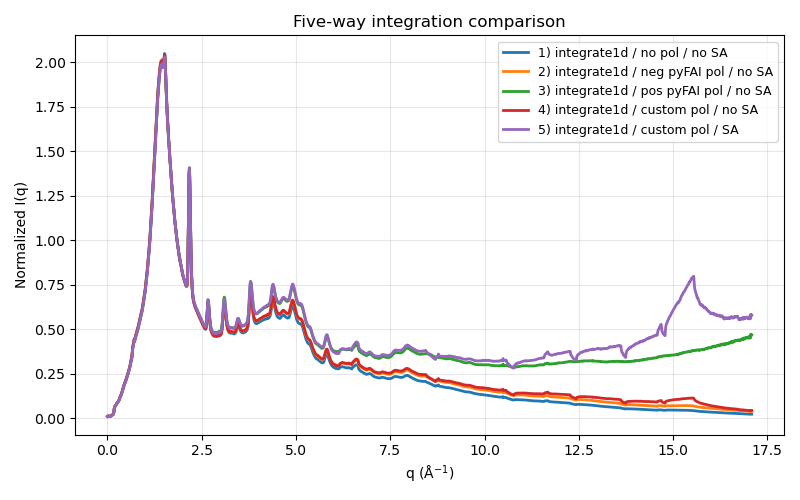

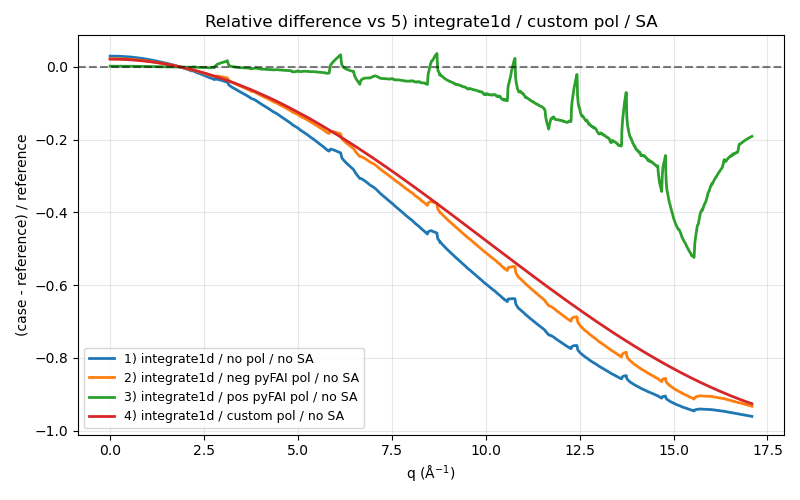

1) integrate1d / no pol / no SA
{'pixel1': 0.000172, 'pixel2': 0.000172, 'distance': 0.17236, 'wavelength': 3.9738514824147314e-11, 'tilt_angle': np.float64(0.0), 'tilt_plane_rotation': np.float64(1.5707963267948966), 'rot1': np.float64(0.0), 'rot2': np.float64(0.0), 'rot3': 0.0, 'polarization_factor': None, 'use_custom_polarization': False, 'integration_function': 'integrate1d', 'correct_solid_angle': False}
------------------------------------------------------------
2) integrate1d / neg pyFAI pol / no SA
{'pixel1': 0.000172, 'pixel2': 0.000172, 'distance': 0.17236, 'wavelength': 3.9738514824147314e-11, 'tilt_angle': np.float64(0.0), 'tilt_plane_rotation': np.float64(1.5707963267948966), 'rot1': np.float64(0.0), 'rot2': np.float64(0.0), 'rot3': 0.0, 'polarization_factor': -0.0999, 'use_custom_polarization': False, 'integration_function': 'integrate1d', 'correct_solid_angle': False}
------------------------------------------------------------
3) integrate1d / pos pyFAI pol / no SA
{'p

In [ ]:
# ----------------------------
# choose one image
# ----------------------------
idx = 0  # change as needed
image = data_dict["images"][idx]
center = (CENTER_X, CENTER_Y)

# use the same mask you normally use
# examples:
# integration_mask = None
integration_mask = np.isnan(image)
# integration_mask = your_mask_variable

# ----------------------------
# common settings
# ----------------------------
common_kwargs = dict(
    images=image,
    centers_xy=center,
    npt=2000,
    unit="q_A^-1",
    radial_range=None,
    nan_radial_range=None,
    azimuth_range=None,
    integration_mask=integration_mask,
    dark=None,
    flat=None,
    method=("bbox", "csr", "cython"),
)

# ----------------------------
# helper
# ----------------------------
def normalize_to_range(q, I, qmin=NORM_MIN, qmax=NORM_MAX):
    qmask = (q >= qmin) & (q <= qmax) & np.isfinite(I)
    if not np.any(qmask):
        raise ValueError(f"No valid points in normalization range {qmin} to {qmax}")
    return I / np.nanmean(I[qmask])

# ----------------------------
# run 5 cases
# ----------------------------
cases = {
    "1) integrate1d / no pol / no SA": dict(
        polarization_factor=None,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
    ),
    "2) integrate1d / neg pyFAI pol / no SA": dict(
        polarization_factor=-0.0999,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=False,
    ),
    "3) integrate1d / pos pyFAI pol / no SA": dict(
        polarization_factor=0.999,
        use_custom_polarization=False,
        integration_function="integrate1d",
        correct_solid_angle=True,
    ),
    "4) integrate1d / custom pol / no SA": dict(
        polarization_factor=0.999,
        use_custom_polarization=True,
        integration_function="integrate1d",
        correct_solid_angle=False,
    ),
    "5) integrate1d / custom pol / SA": dict(
        polarization_factor=0.999,
        use_custom_polarization=True,
        integration_function="integrate1d",
        correct_solid_angle=True,
    ),
}

results = {}

for label, opts in cases.items():
    res = trxrd.azimuthal_average_pyfai(
        **common_kwargs,
        **opts,
        return_dict=True,
        error_mode="raise",
        max_workers=1,
        progress_interval=1,
    )

    q = res["radial"]
    I = res["profiles"][0]
    I_norm = normalize_to_range(q, I, qmin=1.0, qmax=3.0)

    results[label] = {
        "q": q,
        "I": I,
        "I_norm": I_norm,
        "meta": res["geometry"],
    }

# ----------------------------
# overlay normalized curves
# ----------------------------
plt.figure(figsize=(8, 5))
for label, out in results.items():
    plt.plot(out["q"], out["I_norm"], label=label, lw=2)

plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Normalized I(q)")
plt.title("Five-way integration comparison")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# plot relative differences to case 5
# ----------------------------
ref_label = "5) integrate1d / custom pol / SA"
q_ref = results[ref_label]["q"]
I_ref = results[ref_label]["I_norm"]

plt.figure(figsize=(8, 5))
for label, out in results.items():
    if label == ref_label:
        continue
    rel = (out["I_norm"] - I_ref) / I_ref
    plt.plot(q_ref, rel, label=label, lw=2)

plt.axhline(0, color="k", ls="--", alpha=0.5)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("(case - reference) / reference")
plt.title(f"Relative difference vs {ref_label}")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ----------------------------
# print the options used
# ----------------------------
for label, out in results.items():
    print(label)
    print(out["meta"])
    print("-" * 60)